In [ ]:
# !pip install torch torchvision matplotlib numpy

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from tqdm import tqdm
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
BATCH_SIZE = 128
NUM_CLASSES = 10
LATENT_DIM = 32
# LR = 3e-4
EPOCHS = 40
LR = 1e-3
BETA = 0.1


transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Размер тренировочного датасета: {len(train_dataset)}")
print(f"Размер тестового датасета: {len(test_dataset)}")

Размер тренировочного датасета: 60000
Размер тестового датасета: 10000


In [ ]:
class ConditionalVAE(nn.Module):
    def __init__(self, latent_dim=20, num_classes=10):
        super(ConditionalVAE, self).__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes

        self.encoder = nn.Sequential(
            nn.Conv2d(1 + num_classes, 32, kernel_size=3, stride=2, padding=1),  # 14x14
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 7x7
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),  # 7x7
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Flatten()
        )

        self.fc_mu = nn.Linear(128 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(128 * 7 * 7, latent_dim)

        self.decoder_input = nn.Linear(latent_dim + num_classes, 128 * 7 * 7)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (128, 7, 7)),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=1, padding=1),
        )

    def encode(self, x, labels):
        batch_size = x.size(0)
        one_hot_labels = F.one_hot(labels, self.num_classes).float().to(device)  # [batch, 10]
        one_hot_labels = one_hot_labels.view(batch_size, self.num_classes, 1, 1)  # [batch, 10, 1, 1]
        one_hot_labels = one_hot_labels.expand(-1, -1, x.size(2), x.size(3))  # [batch, 10, 28, 28]

        x_cond = torch.cat([x, one_hot_labels], dim=1)  # [batch, 11, 28, 28]

        h = self.encoder(x_cond)

        # параметры распределения
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, labels):
        one_hot_labels = F.one_hot(labels, self.num_classes).float().to(device)  # [batch, 10]

        z_cond = torch.cat([z, one_hot_labels], dim=1)  # [batch, latent_dim + 10]

        h = self.decoder_input(z_cond)
        reconstruction = self.decoder(h)
        return reconstruction

    def forward(self, x, labels):
        mu, logvar = self.encode(x, labels)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z, labels)

        return reconstruction, mu, logvar

    def generate(self, z, labels):
        with torch.no_grad():
            generated = self.decode(z, labels)
        return generated

def vae_loss(recon_x, x, mu, logvar, beta=0.1):

    # 1
    recon_loss = F.binary_cross_entropy_with_logits(recon_x, x, reduction='mean')

    # 2
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    # баланс
    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss


In [ ]:
model = ConditionalVAE(latent_dim=LATENT_DIM, num_classes=NUM_CLASSES).to(device)
print(model)

ConditionalVAE(
  (encoder): Sequential(
    (0): Conv2d(11, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=6272, out_features=32, bias=True)
  (fc_logvar): Linear(in_features=6272, out_features=32, bias=True)
  (decoder_input): Linear(in_features=42, out_features=6272, bias=True)
  (decoder): Sequential(
    (0): Unflatten(dim=1, unflattened_size=(128, 7, 7))
    (1): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), o

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=LR)

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}')

    for batch_idx, (data, labels) in enumerate(pbar):
        data = data.to(device)
        labels = labels.to(device)

        # forward
        recon_batch, mu, logvar = model(data, labels)

        loss, recon_loss, kl_loss = vae_loss(recon_batch, data, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        pbar.set_postfix({
            'Loss': loss.item(),
            'Recon': recon_loss.item(),
            'KL': kl_loss.item()
        })

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for data, labels in test_loader:
            data = data.to(device)
            labels = labels.to(device)
            recon_batch, mu, logvar = model(data, labels)
            loss, _, _ = vae_loss(recon_batch, data, mu, logvar)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(test_loader)
    val_losses.append(avg_val_loss)

    print(f'Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}')

Epoch 1/40: 100%|██████████| 469/469 [00:11<00:00, 41.58it/s, Loss=0.173, Recon=0.136, KL=0.369]


Epoch 1: Train Loss = 0.2039, Val Loss = 0.1721


Epoch 2/40: 100%|██████████| 469/469 [00:10<00:00, 46.85it/s, Loss=0.169, Recon=0.132, KL=0.373]


Epoch 2: Train Loss = 0.1683, Val Loss = 0.1626


Epoch 3/40: 100%|██████████| 469/469 [00:09<00:00, 48.21it/s, Loss=0.164, Recon=0.126, KL=0.38]


...

Epoch 38: Train Loss = 0.1426, Val Loss = 0.1421


Epoch 39/40: 100%|██████████| 469/469 [00:09<00:00, 50.79it/s, Loss=0.143, Recon=0.108, KL=0.352]


Epoch 39: Train Loss = 0.1426, Val Loss = 0.1425


Epoch 40/40: 100%|██████████| 469/469 [00:09<00:00, 48.98it/s, Loss=0.151, Recon=0.112, KL=0.391]


Epoch 40: Train Loss = 0.1425, Val Loss = 0.1424


Epoch 30: Train Loss = 0.0741, Val Loss = 0.0754

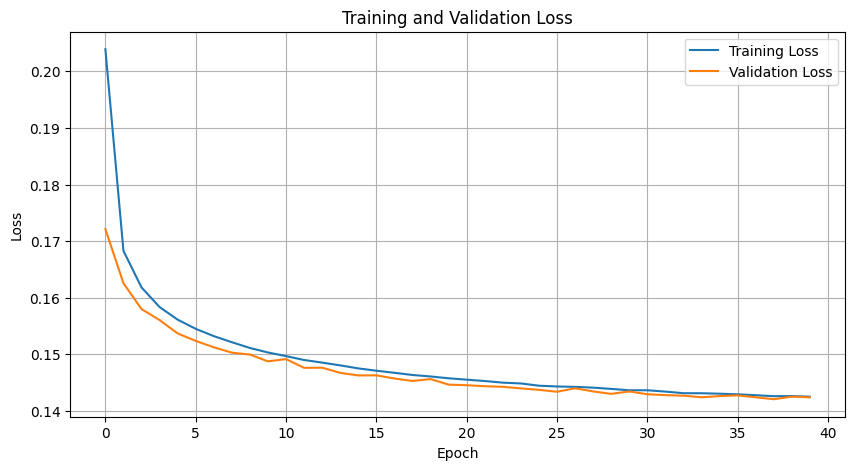

Модель сохранена!


In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

torch.save(model.state_dict(), 'conditional_vae_mnist.pth')
print("Модель сохранена!")

In [ ]:
def generate_and_display_by_class(model, num_samples=5, figsize=(20, 12), use_sigmoid=True):

    model.eval()

    plt.figure(figsize=figsize, dpi=100)

    with torch.no_grad():
        for digit in range(NUM_CLASSES):
            labels = torch.full((num_samples,), digit, dtype=torch.long).to(device)

            # noise
            z = torch.randn(num_samples, LATENT_DIM).to(device) * 0.7

            generated_logits = model.generate(z, labels)

            if use_sigmoid:
                generated = torch.sigmoid(generated_logits)
            else:
                generated = generated_logits

            for j in range(num_samples):
                ax = plt.subplot(NUM_CLASSES, num_samples, digit * num_samples + j + 1)
                img = generated[j].cpu().squeeze().numpy()

                ax.imshow(img, cmap='gray', vmin=0, vmax=1)
                ax.axis('off')

                if j == 0:
                    ax.text(-0.5, 0.5, f'{digit}',
                           transform=ax.transAxes,
                           fontsize=16, fontweight='bold',
                           verticalalignment='center',
                           horizontalalignment='center',
                           bbox=dict(boxstyle="round,pad=0.3",
                                   facecolor='lightblue',
                                   edgecolor='black'))

    plt.suptitle('Генерация цифр по классам',
                 fontsize=20, fontweight='medium', y=0.95)
    plt.tight_layout()
    plt.show()


# ТЕСТ с разными уровнями шума
def test_different_noise_levels(model, digit=5):
    model.eval()

    noise_levels = [0.3, 0.5, 0.7, 1.0, 1.5]

    fig, axes = plt.subplots(1, len(noise_levels), figsize=(15, 3))

    with torch.no_grad():
        for i, noise_std in enumerate(noise_levels):
            # Фиксированный seed
            torch.manual_seed(42 + i)
            z = torch.randn(1, LATENT_DIM).to(device) * noise_std

            label = torch.tensor([digit], dtype=torch.long).to(device)
            generated = torch.sigmoid(model.generate(z, label))

            ax = axes[i]
            img = generated[0].cpu().squeeze().numpy()
            ax.imshow(img, cmap='gray', vmin=0, vmax=1)
            ax.set_title(f'σ={noise_std}', fontsize=12)
            ax.axis('off')

    plt.suptitle(f'Влияние уровня шума на генерацию цифры {digit}', fontsize=14)
    plt.tight_layout()
    plt.show()

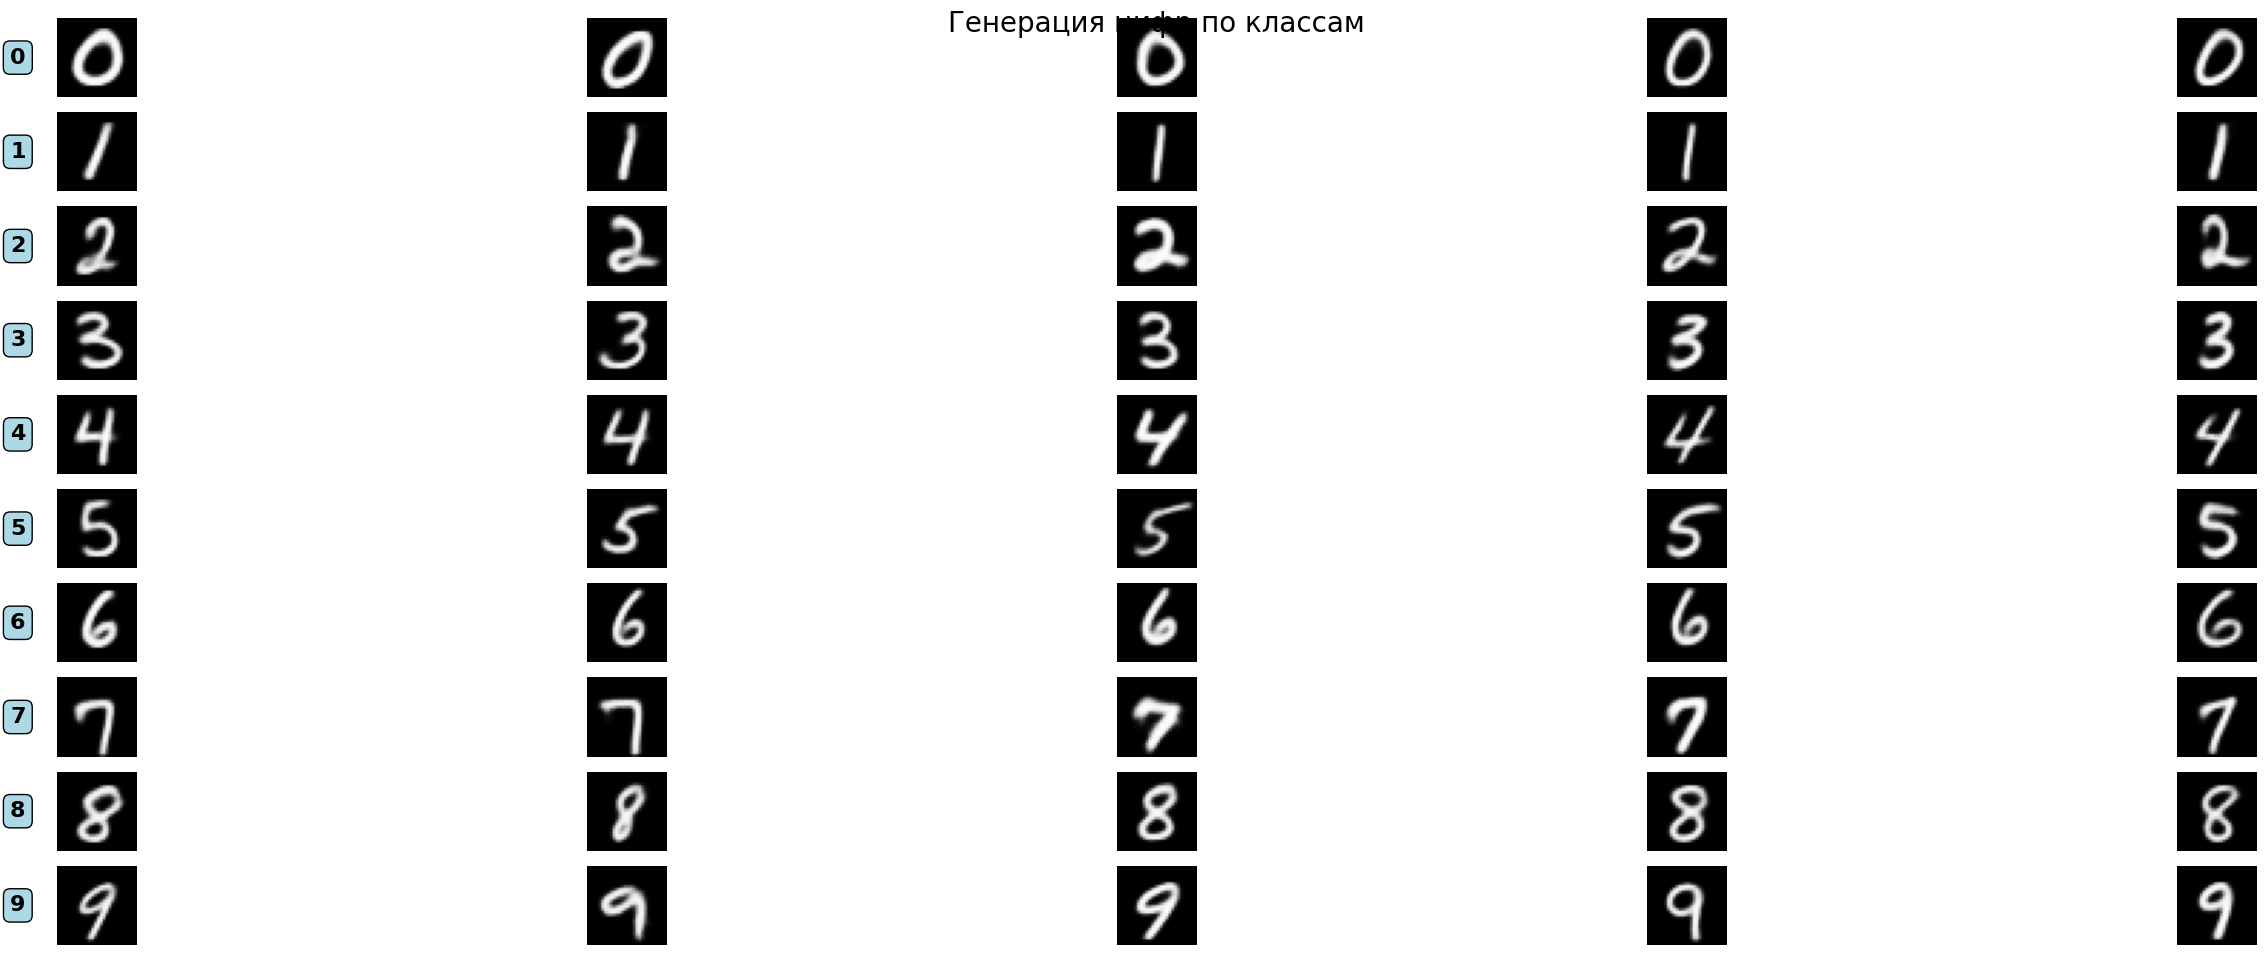

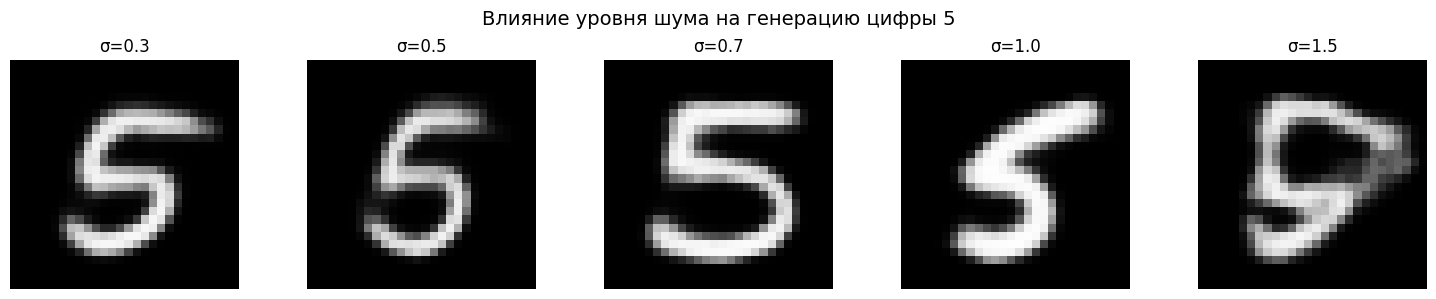

In [ ]:
generate_and_display_by_class(model, num_samples=5, figsize=(30, 10))
test_different_noise_levels(model)